
# 09 - EDA completo del dataset lechero

Este notebook realiza un análisis exploratorio de datos del dataset final con llave:

`(cow_id, date)`

Incluye:

- carga y diagnóstico general
- análisis de valores faltantes
- revisión de variables numéricas
- análisis temporal
- análisis de eventos
- correlaciones con producción
- funciones para graficar la historia de una vaca con eventos
- preparación básica de variables para modelado

> Recomendación: ejecuta este notebook después de generar `training_dataset.parquet` con el notebook de merge.


## 1. Importaciones

In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


## 2. Carga del dataset

In [2]:

def resolve_path(filename: str) -> Path:
    candidates = [
        Path(filename),
        Path("./") / filename,
        Path("/mnt/data") / filename,
        Path("./outputs") / filename,
        Path("../outputs") / filename,
        Path("../data/processed") / filename,
        Path("../data/interim") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError(f"No se encontró {filename}")

PATH_DATASET = resolve_path("training_dataset.parquet")
print("Dataset encontrado en:", PATH_DATASET)

df = pd.read_parquet(PATH_DATASET)

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()

print("Shape:", df.shape)
display(df.head())


Dataset encontrado en: /Users/josemanuelromoperedo/Desktop/ProyectoGranja/data/processed/training_dataset.parquet
Shape: (18345, 175)


,cow_id,date,ordenos_dia,produccion_kg,duracion_total_min,duracion_prom_min,intervalo_ordeno_prom_min,di_mean,dd_mean,td_mean,ti_mean,ubre,destino_leche,ms,source_file,rumia_min,days_in_milk,group_id,last_calving,event_count,event_types,raw_event_text,diagnosis_text,medication_text,treatment_text,diagnosis_categories,treatment_categories,medication_categories,body_condition_score,weight_kg,liters_at_dryoff,dcc_at_dryoff,del_at_dryoff,gestant_insem_number,pregnancy_positive,pregnancy_negative,mastitis_flag,digestive_flag,vaccine_flag,reproductive_flag,abortion_flag,antibiotic_flag,hormone_flag,dryoff_related_flag,fresh_cow_flag,rumen_bolus_flag,heat_flag,insemination_flag,calving_flag,dryoff_flag,Cambio_Grupo,Cambio_ID,Cambio_ID_Tran,Cambio_Tabla_Alim,Celo,Condicion_Corporal,Control_Gestacion,Diagnostico_Tratamiento,Entrada,Inseminacion,Invitacion_Visita,Parto,Peso,Secado,diag_alta,diag_bolo_rumensin,diag_digestivo,diag_gnrh,diag_mastitis,diag_other,diag_pg,diag_presynch,diag_problema_podal,diag_revision,diag_secado,diag_secado_baja,diag_sincronizacion,diag_vacia,diag_vacuna,diag_vitamina,trt_antibiotico,trt_bolo_rumensin,trt_cefa,trt_cidr,trt_gnrh,trt_other,trt_pg,trt_vacuna,trt_vitamina,med_antibiotico,med_bolo_rumensin,med_cefa,med_cidr,med_gnrh,med_other,med_pg,med_vacuna,temperature_2m_mean,temperature_2m_min,temperature_2m_max,relative_humidity_2m_mean,pressure_msl_mean,precipitation_sum,wind_speed_10m_mean,n_corrales,kg_am_total,kg_pm_total,kg_totales_total,sobrante_total,consumo_total,rechazo_total,kg_am_prom_corral,kg_pm_prom_corral,kg_totales_prom_corral,consumo_prom_corral,ratio_consumo_oferta_global,ratio_sobrante_oferta_global,ratio_rechazo_consumo_global,diet_period,consumo_kg_vaca,am_pm_fraction,n_ingredientes,diet_dm_total,diet_wet_total,diet_pct_ms_total,usa_oro_milk,usa_oro_balance,usa_silo_maiz,usa_silo_avena,usa_ensilado,usa_heno,usa_triticale,usa_melaza,usa_soya,diet_kg_seca_agua,diet_kg_seca_maiz_molido,diet_kg_seca_melaza50pct_agua,diet_kg_seca_oro_balance,diet_kg_seca_oro_milk,diet_kg_seca_pasta_se_soya,diet_kg_seca_pata_de_cebada,diet_kg_seca_silo_de_avena,diet_kg_seca_silo_de_maiz,diet_kg_seca_triticale,diet_kg_humeda_agua,diet_kg_humeda_maiz_molido,diet_kg_humeda_melaza50pct_agua,diet_kg_humeda_oro_balance,diet_kg_humeda_oro_milk,diet_kg_humeda_pasta_se_soya,diet_kg_humeda_pata_de_cebada,diet_kg_humeda_silo_de_avena,diet_kg_humeda_silo_de_maiz,diet_kg_humeda_triticale,diet_pct_ms_agua,diet_pct_ms_maiz_molido,diet_pct_ms_melaza50pct_agua,diet_pct_ms_oro_balance,diet_pct_ms_oro_milk,diet_pct_ms_pasta_se_soya,diet_pct_ms_pata_de_cebada,diet_pct_ms_silo_de_avena,diet_pct_ms_silo_de_maiz,diet_pct_ms_triticale,diet_kg_am_pm_agua,diet_kg_am_pm_maiz_molido,diet_kg_am_pm_melaza50pct_agua,diet_kg_am_pm_oro_balance,diet_kg_am_pm_oro_milk,diet_kg_am_pm_pasta_se_soya,diet_kg_am_pm_pata_de_cebada,diet_kg_am_pm_silo_de_avena,diet_kg_am_pm_silo_de_maiz,diet_kg_am_pm_triticale,has_event
0,1204,2022-06-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,Entrada,User1,,,,,,,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.204167,14.3,29.6,45.750000,1011.283333,0.0,8.470833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1204,2022-06-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,Cambio ID,User1 Nacimiento,,,,,,,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

## 3. Vista general

In [3]:

print("Filas:", len(df))
print("Columnas:", df.shape[1])
print("Vacas únicas:", df["cow_id"].nunique() if "cow_id" in df.columns else "N/A")
print("Fechas únicas:", df["date"].nunique() if "date" in df.columns else "N/A")
print("Rango de fechas:", df["date"].min(), "->", df["date"].max() if "date" in df.columns else "N/A")

display(df.info())
display(df.describe(include="all").T.head(50))


Filas: 18345
Columnas: 175
Vacas únicas: 78
Fechas únicas: 999
Rango de fechas: 2021-04-03 00:00:00 -> 2025-12-31 00:00:00
<class 'pandas.DataFrame'>
RangeIndex: 18345 entries, 0 to 18344
Columns: 175 entries, cow_id to has_event
dtypes: Int64(1), datetime64[us](2), float64(158), int64(2), str(12)
memory usage: 25.5 MB


None

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
cow_id,18345.0,<NA>,<NA>,<NA>,4590.212428,1204.0,1619.0,6012.0,6194.0,8781.0,2828.939841
date,18345,NaN,NaN,NaN,2025-03-11 17:15:35.470155,2021-04-03 00:00:00,2025-02-05 00:00:00,2025-04-24 00:00:00,2025-07-18 00:00:00,2025-12-31 00:00:00,NaN
ordenos_dia,9814.0,NaN,NaN,NaN,2.421337,1.0,2.0,2.0,3.0,6.0,0.773739
produccion_kg,9814.0,NaN,NaN,NaN,37.56212,0.0,28.56,36.86,45.95,89.79,12.959906
duracion_total_min,9814.0,NaN,NaN,NaN,19.376348,4.25,14.133333,18.425,23.633333,62.033333,7.461055
duracion_prom_min,9814.0,NaN,NaN,NaN,8.163624,3.991667,6.466667,7.633333,9.272222,22.083333,2.336762
intervalo_ordeno_prom_min,9814.0,NaN,NaN,NaN,664.68443,0.0,489.666667,579.0,710.0,138403.0,1633.850519
di_mean,9793.0,NaN,NaN,NaN,3.650414,0.0,2.74,3.565,4.57,11.38,1.592303
dd_mean,9587.0,NaN,NaN,NaN,3.975071,0.0,3.105,3.87,4.77,10.46,1.385259
td_mean,9808.0,NaN,NaN,NaN,4.302498,0.0,3.08,4.291667,5.46375,15.42,1.939433


## 4. Tipos de columnas

In [4]:
from pandas.api.types import (
    is_numeric_dtype,
    is_datetime64_any_dtype,
    is_string_dtype,
    is_object_dtype,
)

num_cols = [c for c in df.columns if is_numeric_dtype(df[c])]
date_cols = [c for c in df.columns if is_datetime64_any_dtype(df[c])]
obj_cols = [c for c in df.columns if is_string_dtype(df[c]) or is_object_dtype(df[c])]

print("Numéricas:", len(num_cols))
print("Fechas:", len(date_cols))
print("Texto:", len(obj_cols))

print("\nPrimeras numéricas:", num_cols[:30])
print("\nPrimeras fechas:", date_cols[:30])
print("\nPrimeras de texto:", obj_cols[:30])


Numéricas: 161
Fechas: 2
Texto: 12

Primeras numéricas: ['cow_id', 'ordenos_dia', 'produccion_kg', 'duracion_total_min', 'duracion_prom_min', 'intervalo_ordeno_prom_min', 'di_mean', 'dd_mean', 'td_mean', 'ti_mean', 'ubre', 'rumia_min', 'days_in_milk', 'group_id', 'event_count', 'body_condition_score', 'weight_kg', 'liters_at_dryoff', 'dcc_at_dryoff', 'del_at_dryoff', 'gestant_insem_number', 'pregnancy_positive', 'pregnancy_negative', 'mastitis_flag', 'digestive_flag', 'vaccine_flag', 'reproductive_flag', 'abortion_flag', 'antibiotic_flag', 'hormone_flag']

Primeras fechas: ['date', 'last_calving']

Primeras de texto: ['destino_leche', 'ms', 'source_file', 'event_types', 'raw_event_text', 'diagnosis_text', 'medication_text', 'treatment_text', 'diagnosis_categories', 'treatment_categories', 'medication_categories', 'diet_period']


## 5. Valores faltantes

In [5]:

missing = (
    pd.DataFrame({
        "column": df.columns,
        "nan_count": df.isna().sum().values,
        "nan_pct": (df.isna().mean() * 100).round(2).values,
        "dtype": [str(df[c].dtype) for c in df.columns],
    })
    .sort_values(["nan_pct", "nan_count"], ascending=[False, False])
    .reset_index(drop=True)
)

display(missing.head(100))


,column,nan_count,nan_pct,dtype
0,weight_kg,18343,99.99,float64
1,del_at_dryoff,18340,99.97,float64
2,body_condition_score,18331,99.92,float64
3,gestant_insem_number,18312,99.82,float64
4,liters_at_dryoff,18304,99.78,float64
5,dcc_at_dryoff,18297,99.74,float64
6,diet_kg_seca_maiz_molido,14627,79.73,float64
7,diet_kg_seca_pasta_se_soya,14627,79.73,float64
8,diet_kg_seca_silo_de_avena,14627,79.73,float64
9,diet_kg_seca_silo_de_maiz,14627,79.73,float64


In [6]:
df["mastitis_flag"] = df["mastitis_flag"].fillna(0)

In [7]:
df["is_pregnant"] = (
    df.groupby("cow_id")["pregnancy_positive"]
    .ffill()
    .fillna(0)
)

In [8]:
df = df.drop(columns=[
    "raw_event_text",
    "diagnosis_text",
    "medication_text"
], errors="ignore")

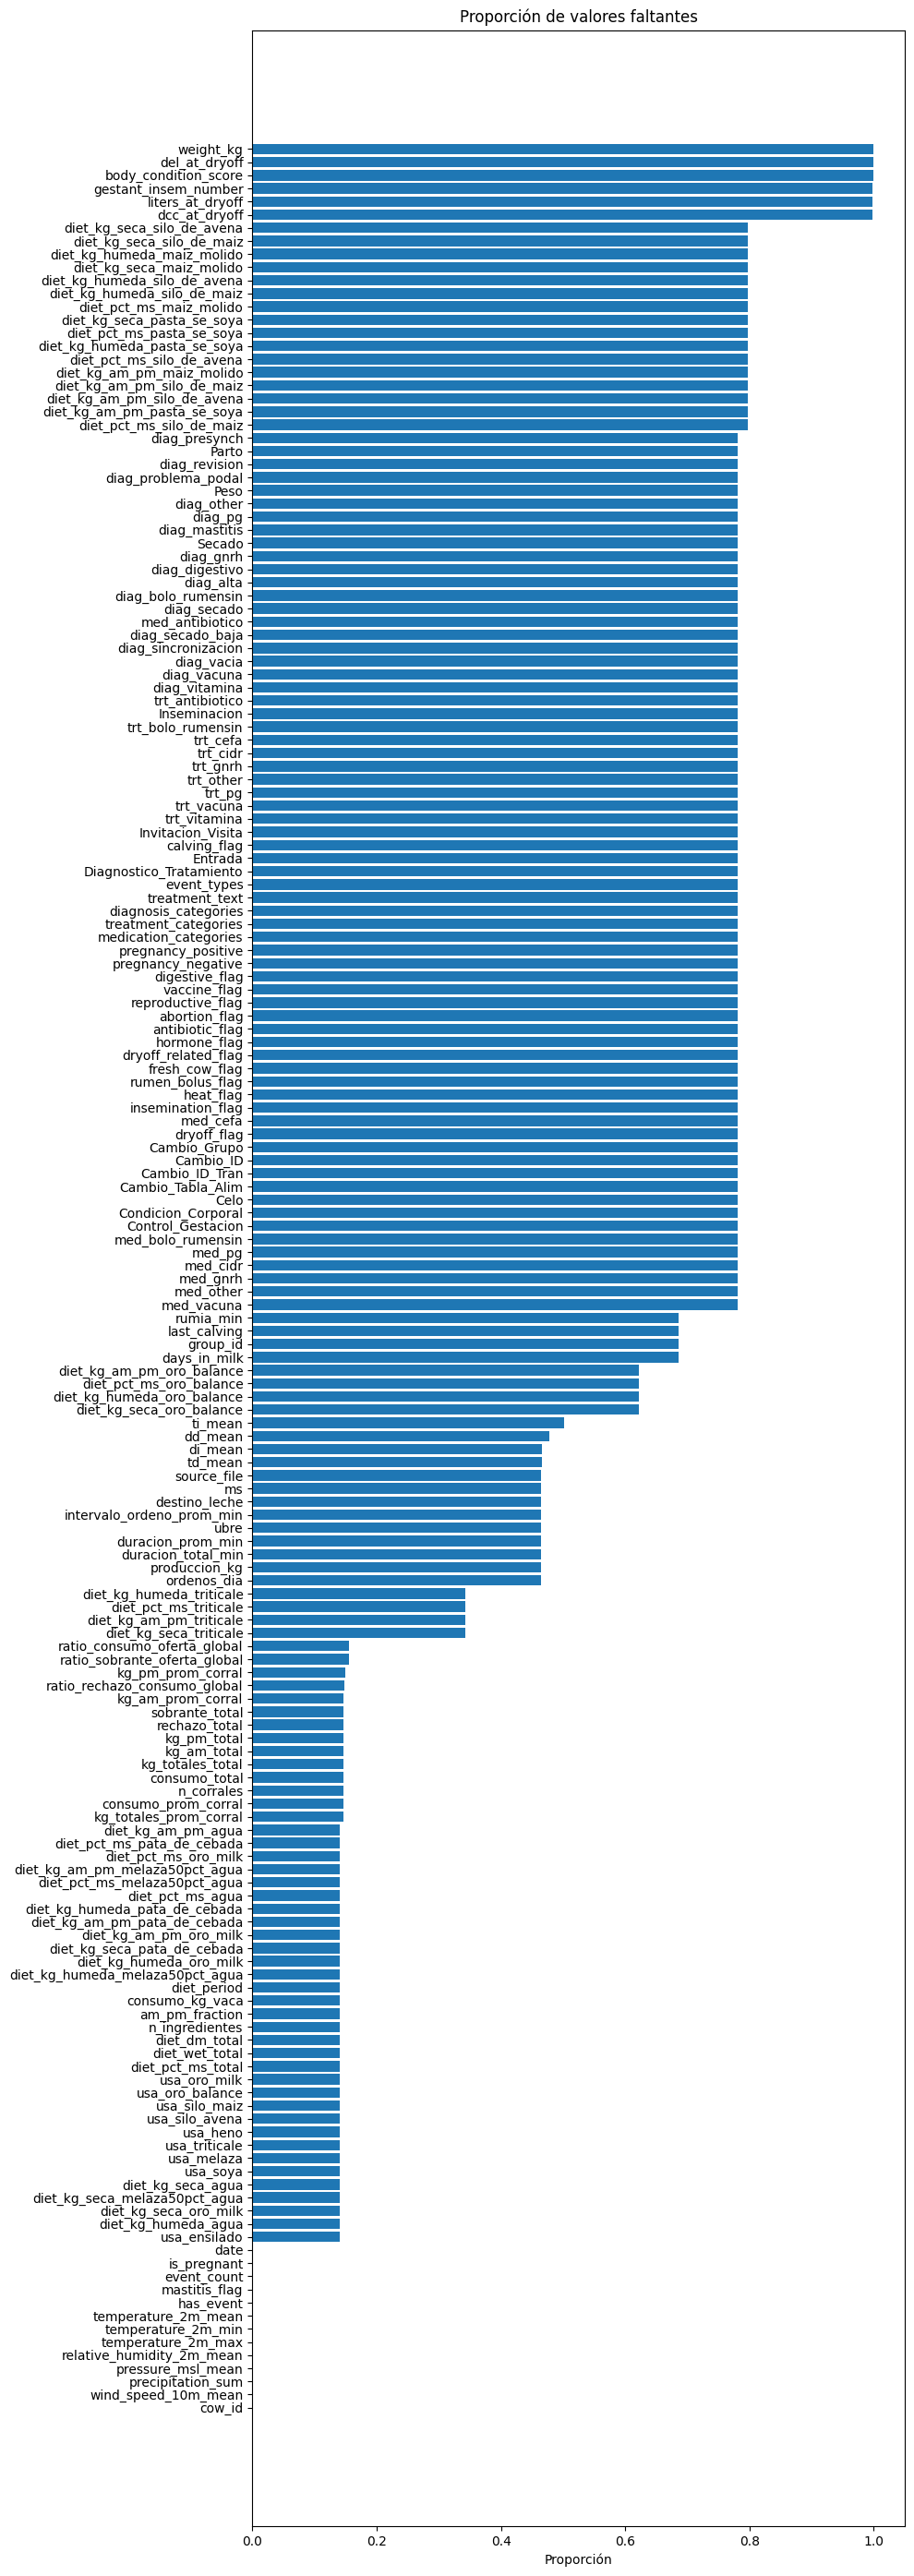

In [9]:

missing_plot = df.isna().mean().sort_values()

plt.figure(figsize=(10, 28))
plt.barh(missing_plot.index, missing_plot.values)
plt.title("Proporción de valores faltantes")
plt.xlabel("Proporción")
plt.tight_layout()
plt.show()


## 6. Clasificación práctica de faltantes

In [10]:

flag_cols = [c for c in df.columns if c.endswith("_flag")]
diag_cols = [c for c in df.columns if c.startswith("diag_")]
trt_cols = [c for c in df.columns if c.startswith("trt_")]
med_cols = [c for c in df.columns if c.startswith("med_")]
event_ohe_cols = [
    c for c in [
        "Cambio_Grupo", "Cambio_ID", "Cambio_ID_Tran", "Cambio_Tabla_Alim",
        "Celo", "Condicion_Corporal", "Control_Gestacion", "Diagnostico_Tratamiento",
        "Entrada", "Inseminacion", "Invitacion_Visita", "Parto", "Peso", "Secado"
    ] if c in df.columns
]

event_like_cols = sorted(set(flag_cols + diag_cols + trt_cols + med_cols + event_ohe_cols))
sparse_measure_cols = [c for c in ["weight_kg", "body_condition_score", "liters_at_dryoff",
                                   "dcc_at_dryoff", "del_at_dryoff", "gestant_insem_number"] if c in df.columns]

print("Columnas tipo evento:", len(event_like_cols))
print("Columnas de medición puntual:", sparse_measure_cols)


Columnas tipo evento: 61
Columnas de medición puntual: ['weight_kg', 'body_condition_score', 'liters_at_dryoff', 'dcc_at_dryoff', 'del_at_dryoff', 'gestant_insem_number']


## 7. Copia de trabajo para EDA y modelado

In [11]:

df_eda = df.copy()

# En variables de evento, NaN normalmente significa ausencia del evento
for c in event_like_cols:
    if c in df_eda.columns:
        df_eda[c] = df_eda[c].fillna(0)

if "event_count" in df_eda.columns:
    df_eda["event_count"] = df_eda["event_count"].fillna(0)

if "has_event" in df_eda.columns:
    df_eda["has_event"] = df_eda["has_event"].fillna(0)

display(df_eda.head())


,cow_id,date,ordenos_dia,produccion_kg,duracion_total_min,duracion_prom_min,intervalo_ordeno_prom_min,di_mean,dd_mean,td_mean,ti_mean,ubre,destino_leche,ms,source_file,rumia_min,days_in_milk,group_id,last_calving,event_count,event_types,treatment_text,diagnosis_categories,treatment_categories,medication_categories,body_condition_score,weight_kg,liters_at_dryoff,dcc_at_dryoff,del_at_dryoff,gestant_insem_number,pregnancy_positive,pregnancy_negative,mastitis_flag,digestive_flag,vaccine_flag,reproductive_flag,abortion_flag,antibiotic_flag,hormone_flag,dryoff_related_flag,fresh_cow_flag,rumen_bolus_flag,heat_flag,insemination_flag,calving_flag,dryoff_flag,Cambio_Grupo,Cambio_ID,Cambio_ID_Tran,Cambio_Tabla_Alim,Celo,Condicion_Corporal,Control_Gestacion,Diagnostico_Tratamiento,Entrada,Inseminacion,Invitacion_Visita,Parto,Peso,Secado,diag_alta,diag_bolo_rumensin,diag_digestivo,diag_gnrh,diag_mastitis,diag_other,diag_pg,diag_presynch,diag_problema_podal,diag_revision,diag_secado,diag_secado_baja,diag_sincronizacion,diag_vacia,diag_vacuna,diag_vitamina,trt_antibiotico,trt_bolo_rumensin,trt_cefa,trt_cidr,trt_gnrh,trt_other,trt_pg,trt_vacuna,trt_vitamina,med_antibiotico,med_bolo_rumensin,med_cefa,med_cidr,med_gnrh,med_other,med_pg,med_vacuna,temperature_2m_mean,temperature_2m_min,temperature_2m_max,relative_humidity_2m_mean,pressure_msl_mean,precipitation_sum,wind_speed_10m_mean,n_corrales,kg_am_total,kg_pm_total,kg_totales_total,sobrante_total,consumo_total,rechazo_total,kg_am_prom_corral,kg_pm_prom_corral,kg_totales_prom_corral,consumo_prom_corral,ratio_consumo_oferta_global,ratio_sobrante_oferta_global,ratio_rechazo_consumo_global,diet_period,consumo_kg_vaca,am_pm_fraction,n_ingredientes,diet_dm_total,diet_wet_total,diet_pct_ms_total,usa_oro_milk,usa_oro_balance,usa_silo_maiz,usa_silo_avena,usa_ensilado,usa_heno,usa_triticale,usa_melaza,usa_soya,diet_kg_seca_agua,diet_kg_seca_maiz_molido,diet_kg_seca_melaza50pct_agua,diet_kg_seca_oro_balance,diet_kg_seca_oro_milk,diet_kg_seca_pasta_se_soya,diet_kg_seca_pata_de_cebada,diet_kg_seca_silo_de_avena,diet_kg_seca_silo_de_maiz,diet_kg_seca_triticale,diet_kg_humeda_agua,diet_kg_humeda_maiz_molido,diet_kg_humeda_melaza50pct_agua,diet_kg_humeda_oro_balance,diet_kg_humeda_oro_milk,diet_kg_humeda_pasta_se_soya,diet_kg_humeda_pata_de_cebada,diet_kg_humeda_silo_de_avena,diet_kg_humeda_silo_de_maiz,diet_kg_humeda_triticale,diet_pct_ms_agua,diet_pct_ms_maiz_molido,diet_pct_ms_melaza50pct_agua,diet_pct_ms_oro_balance,diet_pct_ms_oro_milk,diet_pct_ms_pasta_se_soya,diet_pct_ms_pata_de_cebada,diet_pct_ms_silo_de_avena,diet_pct_ms_silo_de_maiz,diet_pct_ms_triticale,diet_kg_am_pm_agua,diet_kg_am_pm_maiz_molido,diet_kg_am_pm_melaza50pct_agua,diet_kg_am_pm_oro_balance,diet_kg_am_pm_oro_milk,diet_kg_am_pm_pasta_se_soya,diet_kg_am_pm_pata_de_cebada,diet_kg_am_pm_silo_de_avena,diet_kg_am_pm_silo_de_maiz,diet_kg_am_pm_triticale,has_event,is_pregnant
0,1204,2022-06-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,Entrada,,,,,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.204167,14.3,29.6,45.750000,1011.283333,0.0,8.470833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0
1,1204,2022-06-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1,Cambio ID,,,,,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

## 8. Target y variables clave

In [12]:

target_col = "produccion_kg" if "produccion_kg" in df_eda.columns else None
print("Target:", target_col)

core_cols = [c for c in [
    "produccion_kg", "rumia_min", "days_in_milk",
    "temperature_2m_mean", "precipitation_sum",
    "event_count", "has_event",
    "consumo_total", "kg_totales_total",
    "ratio_consumo_oferta_global"
] if c in df_eda.columns]

display(df_eda[core_cols].describe().T if core_cols else pd.DataFrame())


Target: produccion_kg


,count,mean,std,min,25%,50%,75%,max
produccion_kg,9814.0,37.562120,12.959906,0.000000,28.560000,36.860000,45.950000,89.790000
rumia_min,5750.0,1218.290957,628.131269,0.000000,822.000000,1148.000000,1627.500000,3894.000000
days_in_milk,5750.0,272.494087,127.772995,1.000000,222.000000,283.000000,340.000000,820.000000
temperature_2m_mean,18345.0,18.149652,2.664092,8.554167,16.841667,17.879167,19.604167,27.083333
precipitation_sum,18345.0,2.356560,4.932753,0.000000,0.000000,0.000000,1.900000,36.200000
event_count,18345.0,0.363750,0.862104,0.000000,0.000000,0.000000,0.000000,10.000000
has_event,18345.0,0.219406,0.413855,0.000000,0.000000,0.000000,0.000000,1.000000
consumo_total,15648.0,7092.722776,997.954217,-545.000000,6865.000000,7150.000000,7435.000000,12815.000000
kg_totales_total,15648.0,7439.369824,997.833017,0.000000,7150.000000,7535.000000,7840.000000,13300.000000
ratio_consumo_oferta_global,15504.0,0.953919,0.025190,0.856618,0.943571,0.958546,0.971421,1.000000


## 9. Distribuciones principales

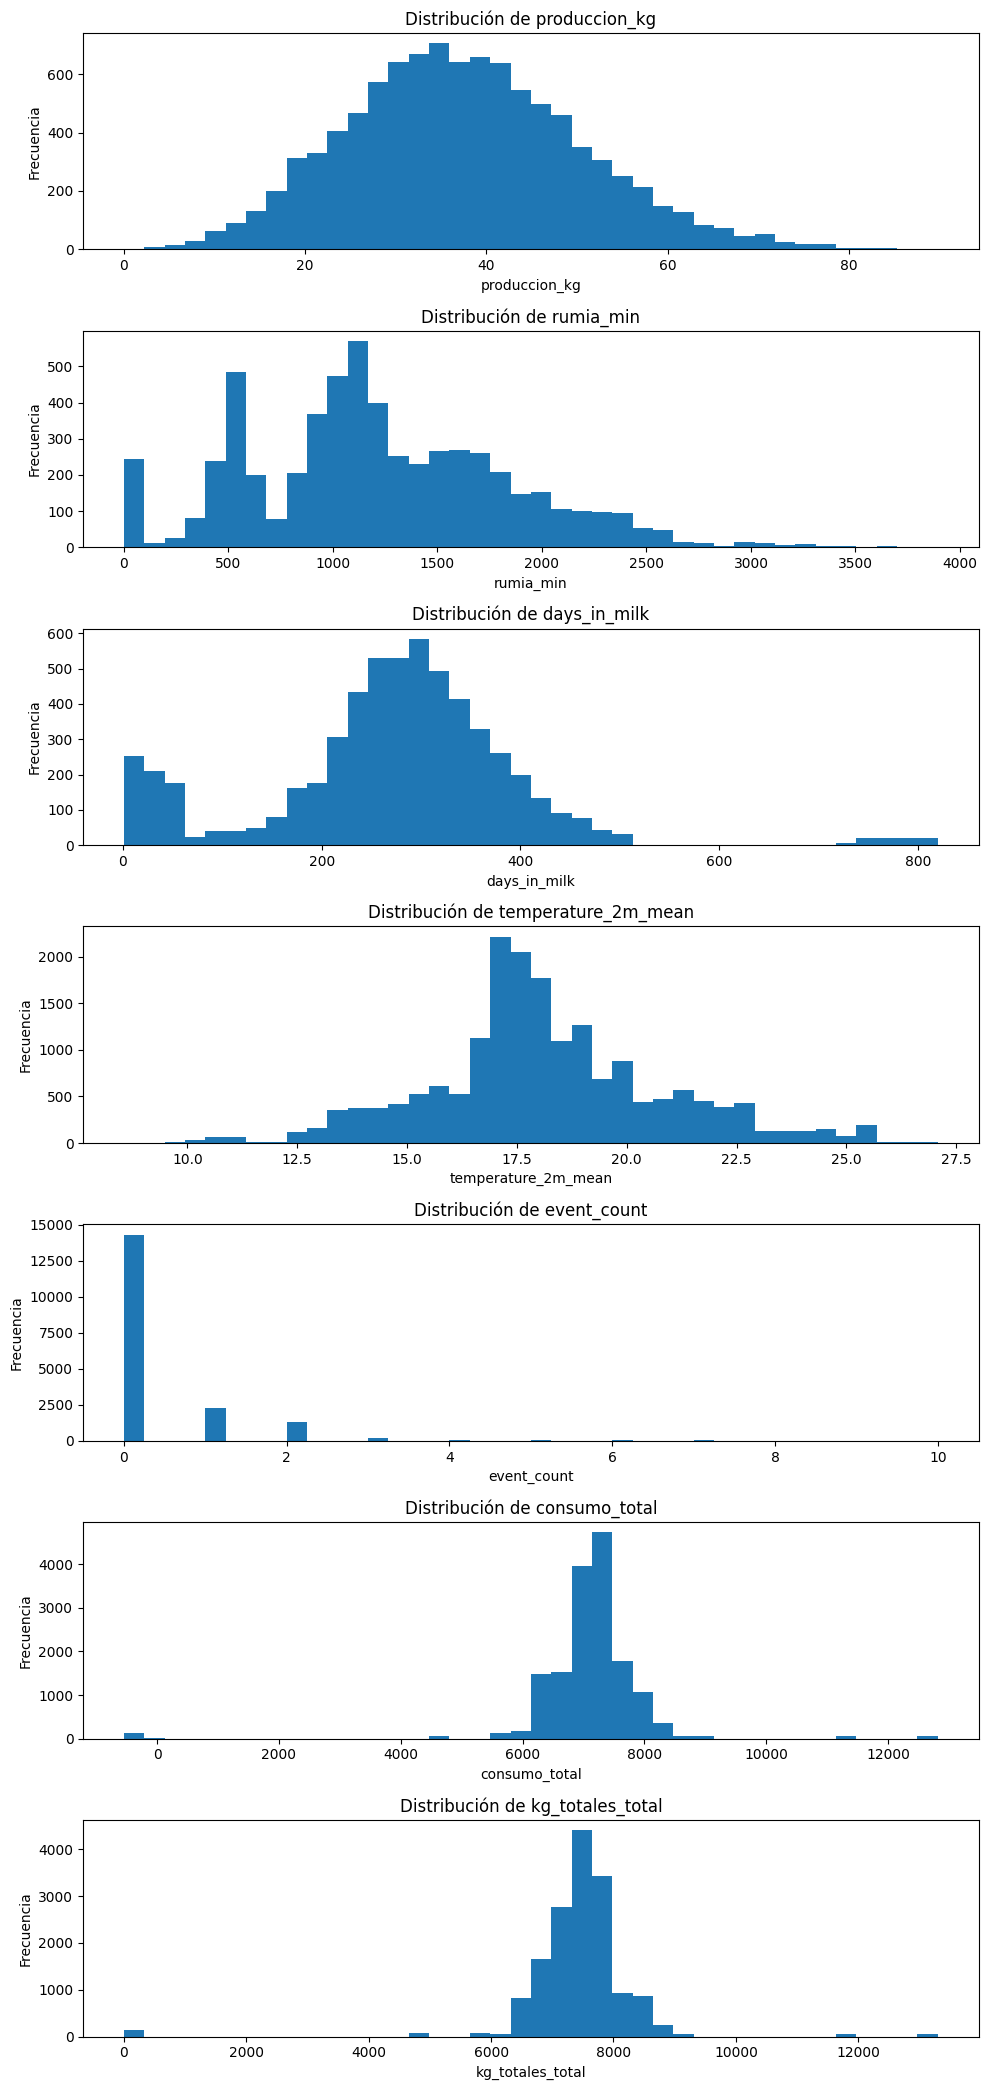

In [13]:

plot_cols = [c for c in [
    "produccion_kg", "rumia_min", "days_in_milk", "temperature_2m_mean",
    "event_count", "consumo_total", "kg_totales_total"
] if c in df_eda.columns]

n = len(plot_cols)
if n > 0:
    fig, axes = plt.subplots(n, 1, figsize=(10, 3*n))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, plot_cols):
        x = pd.to_numeric(df_eda[col], errors="coerce").dropna()
        ax.hist(x, bins=40)
        ax.set_title(f"Distribución de {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()


## 10. Serie temporal agregada

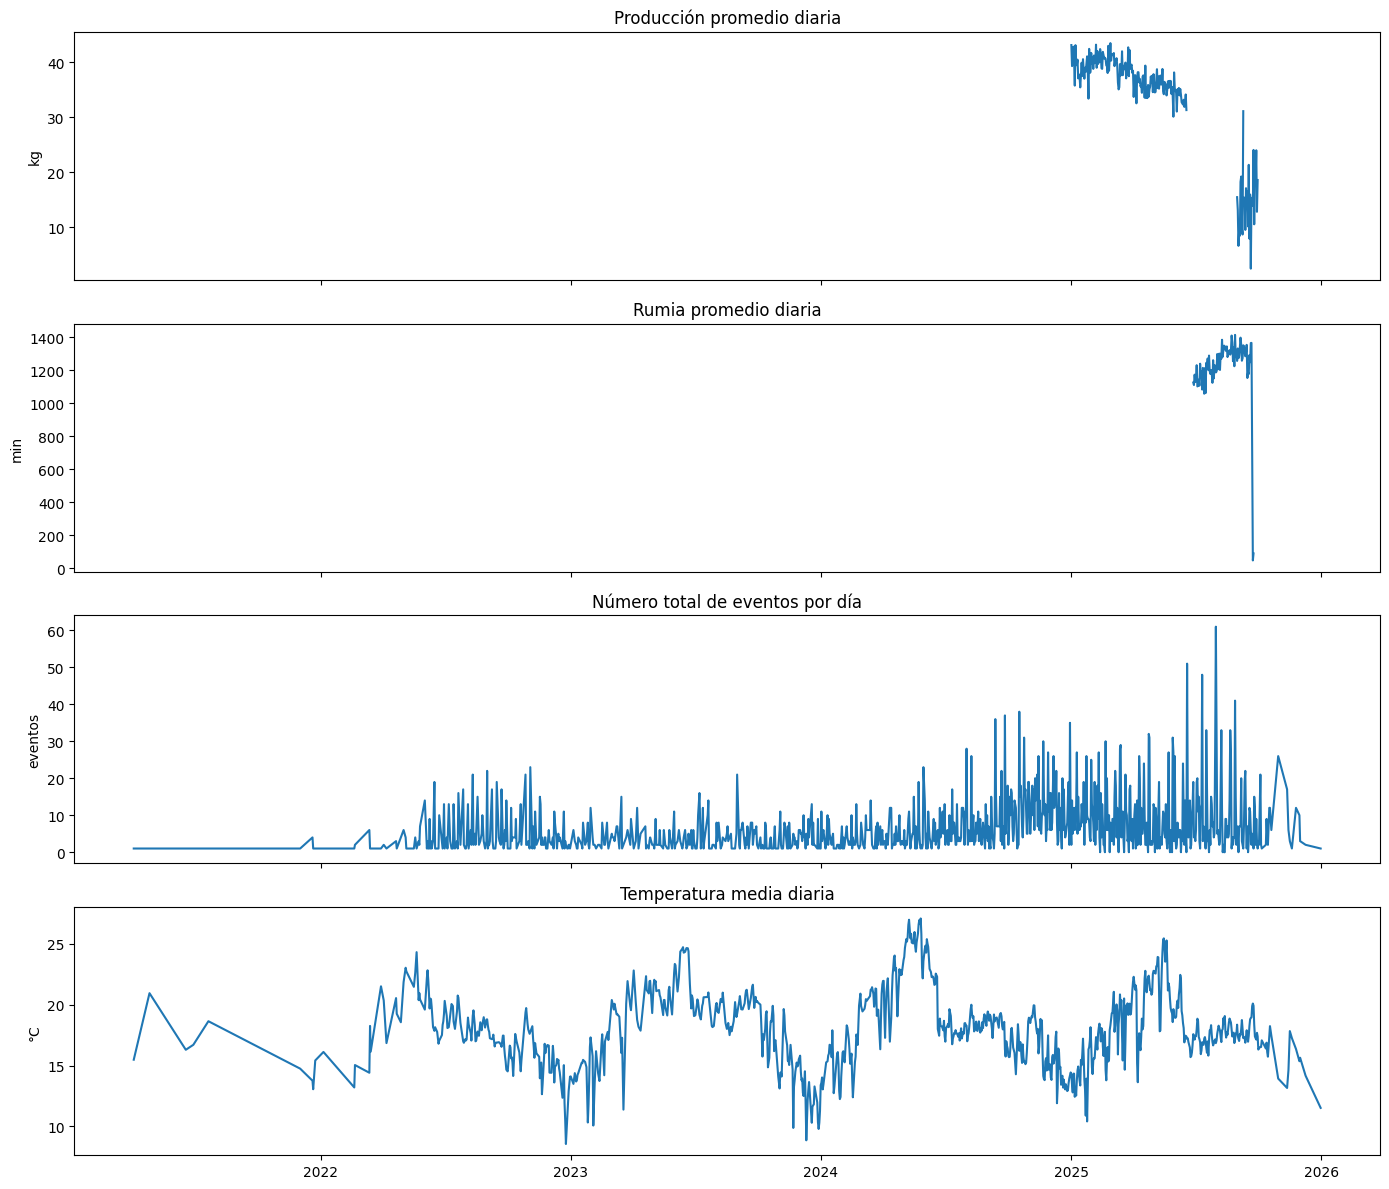

In [14]:

daily_mean = (
    df_eda.groupby("date", as_index=False)
    .agg(
        produccion_kg=("produccion_kg", "mean") if "produccion_kg" in df_eda.columns else ("date", "count"),
        rumia_min=("rumia_min", "mean") if "rumia_min" in df_eda.columns else ("date", "count"),
        event_count=("event_count", "sum") if "event_count" in df_eda.columns else ("date", "count"),
        temperature_2m_mean=("temperature_2m_mean", "mean") if "temperature_2m_mean" in df_eda.columns else ("date", "count"),
    )
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

if "produccion_kg" in daily_mean.columns:
    axes[0].plot(daily_mean["date"], daily_mean["produccion_kg"])
    axes[0].set_title("Producción promedio diaria")
    axes[0].set_ylabel("kg")

if "rumia_min" in daily_mean.columns:
    axes[1].plot(daily_mean["date"], daily_mean["rumia_min"])
    axes[1].set_title("Rumia promedio diaria")
    axes[1].set_ylabel("min")

if "event_count" in daily_mean.columns:
    axes[2].plot(daily_mean["date"], daily_mean["event_count"])
    axes[2].set_title("Número total de eventos por día")
    axes[2].set_ylabel("eventos")

if "temperature_2m_mean" in daily_mean.columns:
    axes[3].plot(daily_mean["date"], daily_mean["temperature_2m_mean"])
    axes[3].set_title("Temperatura media diaria")
    axes[3].set_ylabel("°C")

plt.tight_layout()
plt.show()


## 11. Relaciones bivariadas con producción

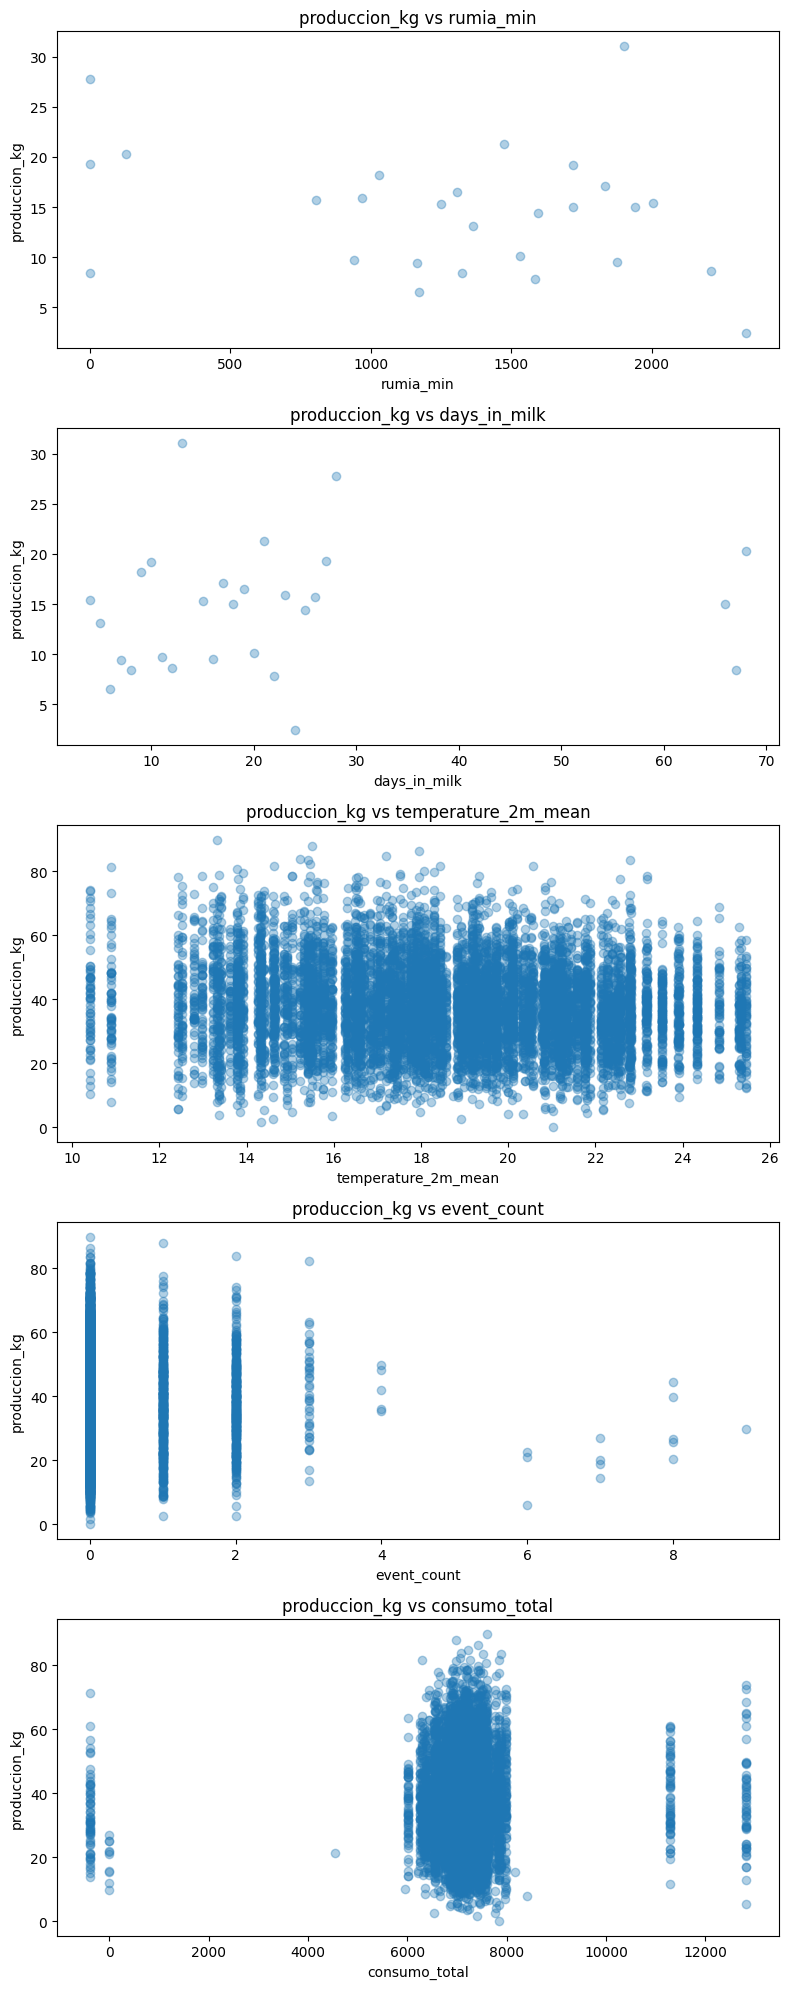

In [15]:

pairs = [
    ("rumia_min", "produccion_kg"),
    ("days_in_milk", "produccion_kg"),
    ("temperature_2m_mean", "produccion_kg"),
    ("event_count", "produccion_kg"),
    ("consumo_total", "produccion_kg"),
]

pairs = [(x, y) for x, y in pairs if x in df_eda.columns and y in df_eda.columns]

if pairs:
    fig, axes = plt.subplots(len(pairs), 1, figsize=(8, 4*len(pairs)))
    if len(pairs) == 1:
        axes = [axes]

    for ax, (x, y) in zip(axes, pairs):
        sub = df_eda[[x, y]].dropna()
        ax.scatter(sub[x], sub[y], alpha=0.35)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(f"{y} vs {x}")

    plt.tight_layout()
    plt.show()


## 12. Correlaciones numéricas

In [16]:

num_df = df_eda.select_dtypes(include=np.number).copy()

if "cow_id" in num_df.columns:
    num_df = num_df.drop(columns=["cow_id"])

corr = num_df.corr(numeric_only=True)

if target_col and target_col in corr.columns:
    target_corr = corr[target_col].sort_values(ascending=False)
    display(target_corr.head(30))
    display(target_corr.tail(30))


del_at_dryoff                    1.000000
produccion_kg                    1.000000
ordenos_dia                      0.676901
liters_at_dryoff                 0.543055
duracion_total_min               0.455277
td_mean                          0.341588
ti_mean                          0.323139
diet_kg_am_pm_oro_balance        0.302519
diet_kg_humeda_oro_balance       0.302519
diet_kg_seca_oro_balance         0.302519
dd_mean                          0.261187
di_mean                          0.239465
dcc_at_dryoff                    0.170483
diet_kg_am_pm_agua               0.132570
diet_kg_seca_agua                0.131402
diet_kg_humeda_agua              0.131402
diet_kg_am_pm_oro_milk           0.128602
diet_kg_seca_oro_milk            0.127757
diet_kg_humeda_oro_milk          0.127757
diet_kg_am_pm_pata_de_cebada     0.126743
diet_kg_humeda_pata_de_cebada    0.125277
diet_kg_seca_pata_de_cebada      0.125277
diet_pct_ms_melaza50pct_agua     0.125277
usa_triticale                    0

Cambio_ID                      NaN
diag_pg                        NaN
med_cidr                       NaN
med_gnrh                       NaN
am_pm_fraction                 NaN
usa_oro_milk                   NaN
usa_ensilado                   NaN
usa_heno                       NaN
usa_melaza                     NaN
diet_kg_seca_maiz_molido       NaN
diet_kg_seca_pasta_se_soya     NaN
diet_kg_seca_silo_de_avena     NaN
diet_kg_seca_silo_de_maiz      NaN
diet_kg_humeda_maiz_molido     NaN
diet_kg_humeda_pasta_se_soya   NaN
diet_kg_humeda_silo_de_avena   NaN
diet_kg_humeda_silo_de_maiz    NaN
diet_pct_ms_agua               NaN
diet_pct_ms_maiz_molido        NaN
diet_pct_ms_oro_balance        NaN
diet_pct_ms_oro_milk           NaN
diet_pct_ms_pasta_se_soya      NaN
diet_pct_ms_pata_de_cebada     NaN
diet_pct_ms_silo_de_avena      NaN
diet_pct_ms_silo_de_maiz       NaN
diet_pct_ms_triticale          NaN
diet_kg_am_pm_maiz_molido      NaN
diet_kg_am_pm_pasta_se_soya    NaN
diet_kg_am_pm_silo_d

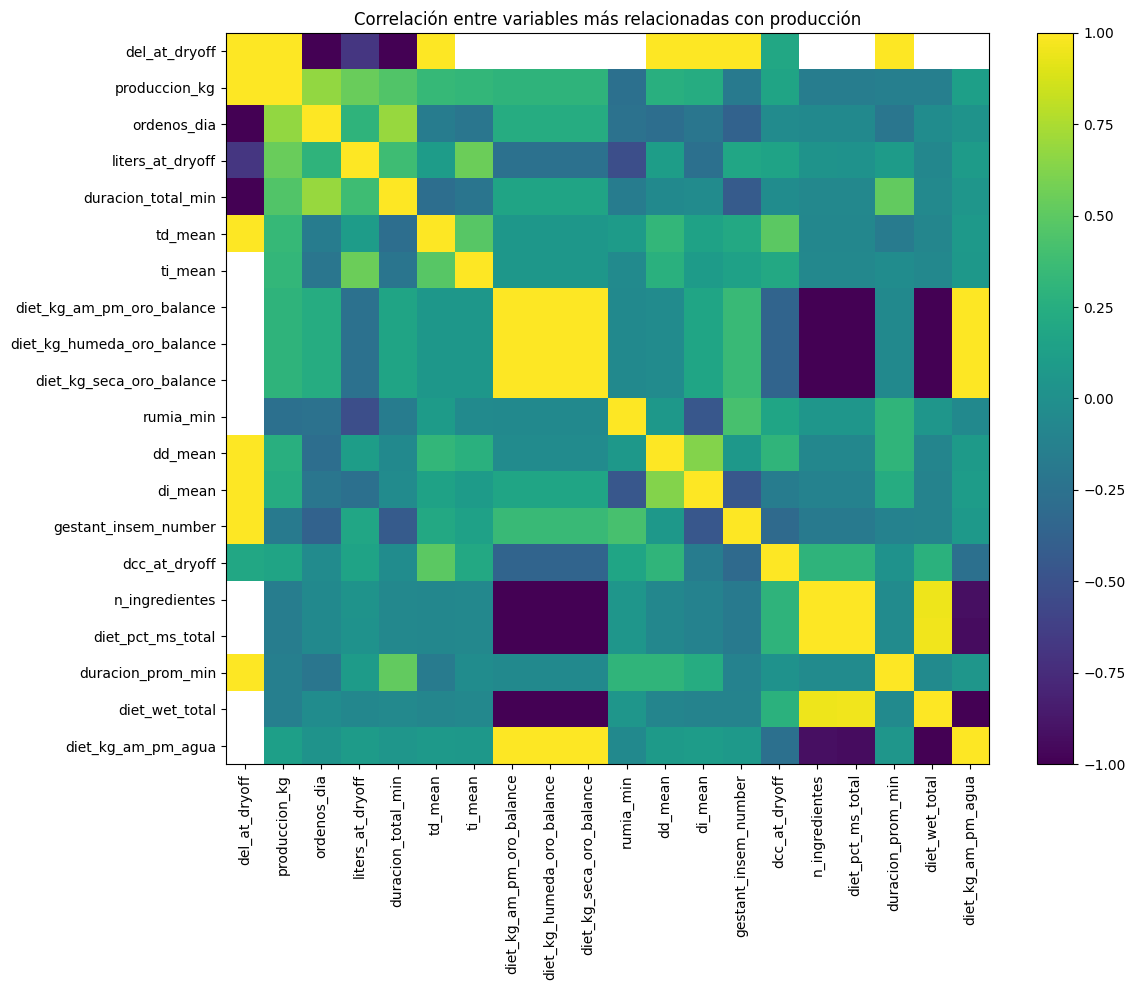

In [17]:

if target_col and target_col in corr.columns:
    top_corr_cols = target_corr.abs().sort_values(ascending=False).head(20).index.tolist()
    heat = corr.loc[top_corr_cols, top_corr_cols]

    plt.figure(figsize=(12, 10))
    plt.imshow(heat, aspect="auto")
    plt.xticks(range(len(heat.columns)), heat.columns, rotation=90)
    plt.yticks(range(len(heat.index)), heat.index)
    plt.title("Correlación entre variables más relacionadas con producción")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


## 13. Eventos más frecuentes

insemination_flag          1332.0
reproductive_flag          1270.0
Invitacion_Visita          1204.0
Diagnostico_Tratamiento     900.0
Cambio_Grupo                875.0
Control_Gestacion           815.0
heat_flag                   689.0
Celo                        661.0
Inseminacion                601.0
fresh_cow_flag              478.0
Cambio_Tabla_Alim           468.0
med_other                   404.0
hormone_flag                368.0
dryoff_related_flag         292.0
antibiotic_flag             241.0
vaccine_flag                239.0
diag_vacuna                 208.0
Condicion_Corporal          184.0
med_vacuna                  182.0
trt_pg                      163.0
calving_flag                160.0
Parto                       160.0
diag_vacia                  134.0
Cambio_ID_Tran              130.0
diag_other                  125.0
mastitis_flag               123.0
diag_mastitis               119.0
dryoff_flag                 116.0
Secado                      116.0
trt_other     

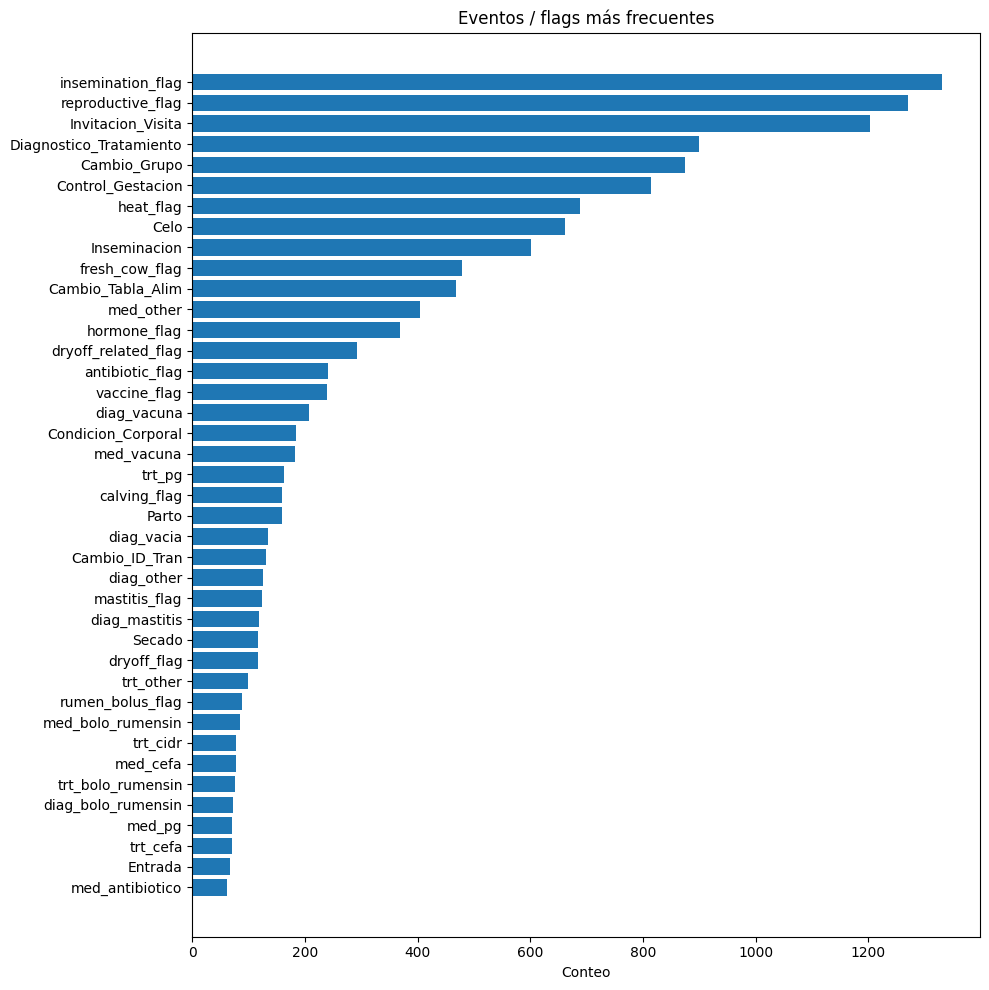

In [26]:

event_presence = {}
for c in event_like_cols:
    if c in df_eda.columns:
        event_presence[c] = df_eda[c].fillna(0).sum()

event_presence = pd.Series(event_presence).sort_values(ascending=False)
display(event_presence.head(40))

plt.figure(figsize=(10, 10))
plt.barh(event_presence.head(40).sort_values().index, event_presence.head(40).sort_values().values)
plt.title("Eventos / flags más frecuentes")
plt.xlabel("Conteo")
plt.tight_layout()
plt.show()


## 14. Producción condicionada a eventos

In [19]:

candidate_event_compare = [c for c in [
    "has_event", "Celo", "Inseminacion", "Parto", "Secado",
    "diag_mastitis", "mastitis_flag", "trt_antibiotico", "med_antibiotico"
] if c in df_eda.columns and target_col in df_eda.columns]

rows = []
for c in candidate_event_compare:
    tmp = df_eda[[c, target_col]].copy()
    tmp[c] = tmp[c].fillna(0)
    grp = tmp.groupby(c)[target_col].mean()
    rows.append({
        "feature": c,
        "mean_when_0": grp.get(0, np.nan),
        "mean_when_1": grp.get(1, np.nan),
        "delta_1_minus_0": grp.get(1, np.nan) - grp.get(0, np.nan),
        "count_1": int((tmp[c] == 1).sum())
    })

event_effect = pd.DataFrame(rows).sort_values("delta_1_minus_0")
display(event_effect)


,feature,mean_when_0,mean_when_1,delta_1_minus_0,count_1
3,Parto,37.568374,22.225000,-15.343374,160
7,trt_antibiotico,37.570260,24.256667,-13.313593,47
4,Secado,37.572587,33.106522,-4.466065,116
8,med_antibiotico,37.570469,33.474000,-4.096469,62
5,diag_mastitis,37.568407,34.886087,-2.682320,119
6,mastitis_flag,37.568407,34.886087,-2.682320,123
0,has_event,37.533387,37.863205,0.329818,4025
2,Inseminacion,37.536309,38.943611,1.407302,601
1,Celo,37.533156,39.053262,1.520106,661


## 15. Funciones para historia de vaca

In [20]:

def _collect_event_dates(cow_df, columns):
    out = {}
    for c in columns:
        if c in cow_df.columns:
            dates = cow_df.loc[cow_df[c].fillna(0) > 0, "date"]
            if len(dates) > 0:
                out[c] = dates
    return out

def plot_cow_history(df_input, cow_id, include_text_events=True):
    cow = df_input[df_input["cow_id"] == cow_id].copy().sort_values("date")
    if cow.empty:
        print(f"No hay datos para cow_id={cow_id}")
        return

    event_cols_plot = [c for c in [
        "Celo", "Inseminacion", "Parto", "Secado",
        "diag_mastitis", "mastitis_flag", "trt_antibiotico",
        "med_antibiotico", "pregnancy_positive", "pregnancy_negative"
    ] if c in cow.columns]

    event_dates = _collect_event_dates(cow, event_cols_plot)

    nrows = 4 if include_text_events else 3
    fig, axes = plt.subplots(nrows, 1, figsize=(16, 11), sharex=True)

    ax0 = axes[0]
    if "produccion_kg" in cow.columns:
        ax0.plot(cow["date"], cow["produccion_kg"], label="Producción kg")
        ax0.set_ylabel("kg")
        ax0.set_title(f"Historia de la vaca {cow_id}")
        ax0.legend()

    ax1 = axes[1]
    if "rumia_min" in cow.columns:
        ax1.plot(cow["date"], cow["rumia_min"], label="Rumia min")
        ax1.set_ylabel("min")
        ax1.legend()

    ax2 = axes[2]
    ypos = 0
    ytick_labels = []
    ytick_pos = []

    for name, dates in event_dates.items():
        ax2.scatter(dates, [ypos] * len(dates), s=30, label=name)
        ytick_labels.append(name)
        ytick_pos.append(ypos)
        ypos += 1

    ax2.set_yticks(ytick_pos)
    ax2.set_yticklabels(ytick_labels)
    ax2.set_title("Eventos")
    ax2.grid(True, axis="x", alpha=0.3)

    if include_text_events:
        ax3 = axes[3]
        if "days_in_milk" in cow.columns:
            ax3.plot(cow["date"], cow["days_in_milk"], label="Days in milk")
        if "temperature_2m_mean" in cow.columns:
            ax3.plot(cow["date"], cow["temperature_2m_mean"], label="Temp media")
        if "event_count" in cow.columns:
            ax3.plot(cow["date"], cow["event_count"], label="Event count")
        ax3.legend()
        ax3.set_title("Contexto adicional")
        ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    if include_text_events:
        text_cols = [c for c in ["event_types", "diagnosis_text", "treatment_text", "medication_text", "raw_event_text"] if c in cow.columns]
        if text_cols:
            history_text = cow.loc[:, ["date"] + text_cols].copy()
            mask = pd.Series(False, index=history_text.index)
            for c in text_cols:
                mask = mask | history_text[c].fillna("").astype(str).str.strip().ne("")
            history_text = history_text[mask]
            display(history_text.tail(50))


### Uso

In [21]:

# Ejemplo:
# plot_cow_history(df_eda, 1204)

sample_cows = df_eda["cow_id"].dropna().astype("Int64").drop_duplicates().sort_values().head(10).tolist()
print("Algunas vacas disponibles:", sample_cows)


Algunas vacas disponibles: [1204, 1213, 1216, 1225, 1228, 1235, 1236, 1242, 1243, 1248]


## 16. Función para comparar varias vacas

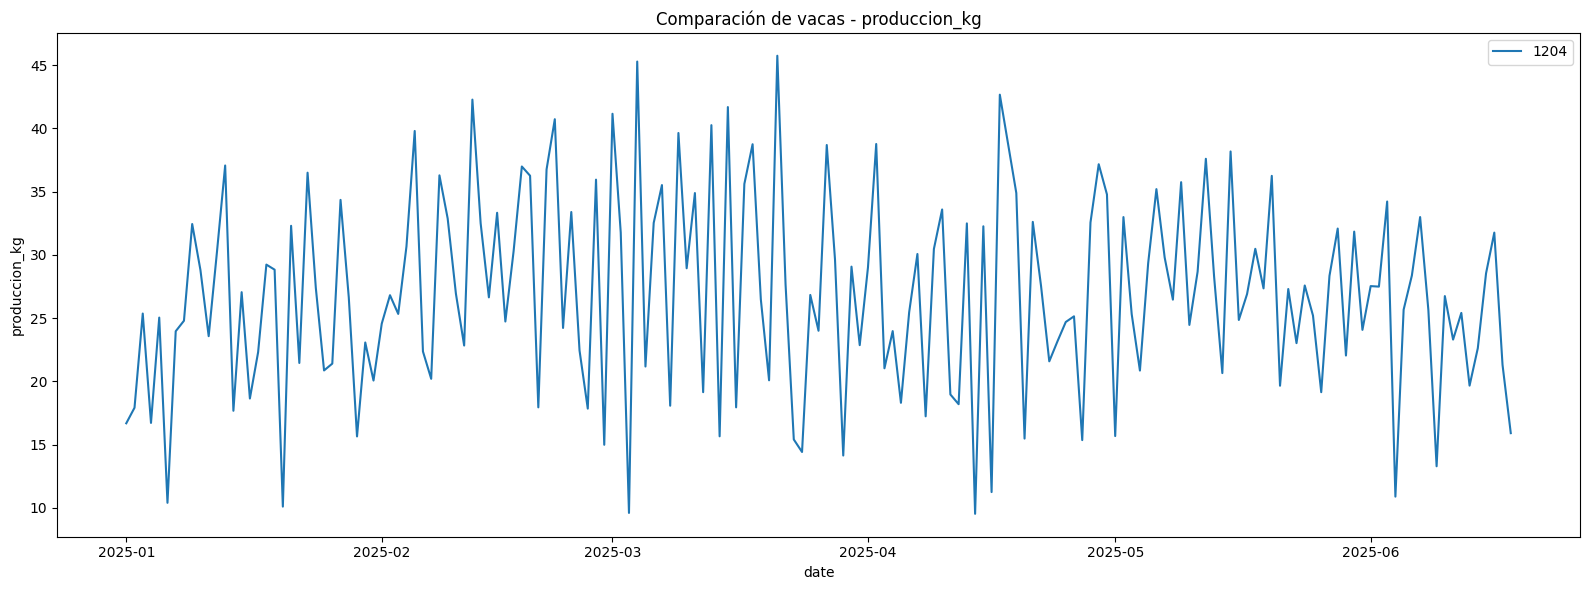

In [29]:

def compare_cows_timeseries(df_input, cow_ids, y_col="produccion_kg"):
    sub = df_input[df_input["cow_id"].isin(cow_ids)].copy().sort_values(["cow_id", "date"])
    if sub.empty or y_col not in sub.columns:
        print("No hay datos suficientes.")
        return

    plt.figure(figsize=(16, 6))
    for cid in cow_ids:
        tmp = sub[sub["cow_id"] == cid]
        if not tmp.empty:
            plt.plot(tmp["date"], tmp[y_col], label=str(cid))
    plt.title(f"Comparación de vacas - {y_col}")
    plt.xlabel("date")
    plt.ylabel(y_col)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Ejemplo:
compare_cows_timeseries(df_eda, [1204], y_col="produccion_kg")


In [ ]:
# Prepare data: production by cow and date
prod_by_cow = df_eda.pivot_table(
    index="cow_id",
    columns="date",
    values="produccion_kg",
    aggfunc="mean"
)

# Select top cows by average production for better visualization
top_cows = prod_by_cow.mean(axis=1).nlargest(20).index
prod_subset = prod_by_cow.loc[top_cows]

# Create heatmap
plt.figure(figsize=(18, 10))
plt.imshow(prod_subset, aspect="auto", cmap="RdYlGn", interpolation="nearest")
plt.colorbar(label="Producción (kg)")
plt.xlabel("Fecha")
plt.ylabel("Vaca ID")
plt.yticks(range(len(prod_subset)), prod_subset.index)
plt.xticks(range(0, len(prod_subset.columns), max(1, len(prod_subset.columns)//10)), 
           [str(d.date()) for d in prod_subset.columns[::max(1, len(prod_subset.columns)//10)]], 
           rotation=45)
plt.title("Producción de leche por vaca - Heatmap")
plt.tight_layout()
plt.show()

## 17. Forward fill opcional de mediciones puntuales por vaca

In [23]:

df_ffill = df_eda.copy().sort_values(["cow_id", "date"])

for c in sparse_measure_cols:
    if c in df_ffill.columns:
        df_ffill[c] = df_ffill.groupby("cow_id")[c].ffill()

display(df_ffill[sparse_measure_cols + [c for c in ["cow_id", "date"] if c in df_ffill.columns]].head(20) if sparse_measure_cols else pd.DataFrame())


,weight_kg,body_condition_score,liters_at_dryoff,dcc_at_dryoff,del_at_dryoff,gestant_insem_number,cow_id,date
0,NaN,NaN,NaN,NaN,NaN,NaN,1204,2022-06-05
1,NaN,NaN,NaN,NaN,NaN,NaN,1204,2022-06-08
2,NaN,NaN,NaN,NaN,NaN,NaN,1204,2022-07-01
3,NaN,NaN,NaN,NaN,NaN,NaN,1204,2022-08-15
4,NaN,NaN,NaN,NaN,NaN,NaN,1204,2022-09-27
5,NaN,NaN,NaN,NaN,NaN,NaN,1204,2023-05-17
6,NaN,NaN,NaN,NaN,NaN,NaN,1204,2023-05-23
7,300.0,NaN,NaN,NaN,NaN,NaN,1204,2023-06-29
8,300.0,NaN,NaN,NaN,NaN,NaN,1204,2023-07-12
9,300.0,NaN,NaN,NaN,NaN,NaN,1204,2023-07-13


## 18. Exportar una copia preparada para modelado

In [24]:

MODEL_OUT = Path("./outputs") / "training_dataset_for_modeling.parquet"
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)

df_model = df_ffill.copy()

# fillna para eventos
for c in event_like_cols:
    if c in df_model.columns:
        df_model[c] = df_model[c].fillna(0)

for c in ["event_count", "has_event"]:
    if c in df_model.columns:
        df_model[c] = df_model[c].fillna(0)

df_model.to_parquet(MODEL_OUT, index=False)
print("Archivo guardado en:", MODEL_OUT.resolve())
print("Shape:", df_model.shape)


Archivo guardado en: /Users/josemanuelromoperedo/Desktop/ProyectoGranja/notebooks/outputs/training_dataset_for_modeling.parquet
Shape: (18345, 173)



## 19. Notas finales

- En columnas de eventos, los `NaN` suelen representar ausencia del evento, por lo que en modelado suele usarse `fillna(0)`.
- En mediciones puntuales como `weight_kg` o `body_condition_score`, una estrategia común es usar `forward fill` por vaca.
- `events.parquet` conserva el detalle por evento.
- `events_daily.parquet` es la versión correcta para el merge con el dataset final.
